<a href="https://colab.research.google.com/github/binsue0/.github/blob/main/ML_day2/2_3_clustering_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering

# Clustering Anaylsis

**군집 분석(Clustering)**은 라벨이 없는 데이터를 유사성에 따라 군집(cluster)으로 분할하는 비지도 학습이다. 같은 군집 내 샘플은 서로 유사하고, 다른 군집 간 샘플은 상이하도록 분할하는 것을 목표로 한다. 대표적으로 중심 기반의 K-Means, 연결 기반의 계층적 군집, 밀도 기반의 DBSCAN이 있다.

## K-Means Clustering

**K-Means**는 군집 수 $k$를 사전에 지정하고, 각 샘플을 가장 가까운 중심(centroid)에 할당한 뒤 중심을 재계산하는 과정을 반복하여 군집 내 제곱합(관성, inertia)을 최소화하는 알고리즘이다.

$$J = \sum_{i=1}^{k} \sum_{x \in C_i} \lVert x - \mu_i \rVert^2$$

절차는 (1) 중심 초기화, (2) 각 샘플을 최근접 중심에 할당, (3) 각 군집의 평균으로 중심 갱신, (4) 수렴할 때까지 (2)–(3) 반복이다. 결과는 초기화에 의존하므로 `n_init`회 반복 후 최적 해를 선택하며, `k-means++`는 중심을 서로 떨어뜨려 초기화하는 방법이다.

### Dataset 만들기

In [ ]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=150,
                  n_features=2,
                  centers=3,
                  cluster_std=0.5,
                  shuffle=True,
                  random_state=0)

### Data Scatter Plot

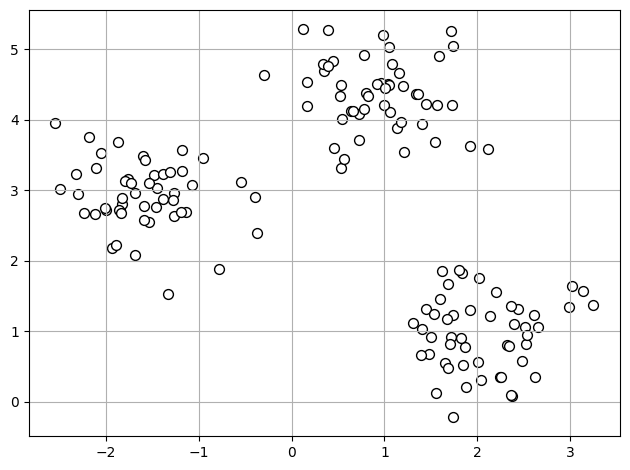

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1],
            c='white', marker='o', edgecolor='black', s=50)
plt.grid()
plt.tight_layout()
plt.show()

### K-Means로 Clustering

In [ ]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3,
            init='random',
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)

y_km = km.fit_predict(X)

### 결과

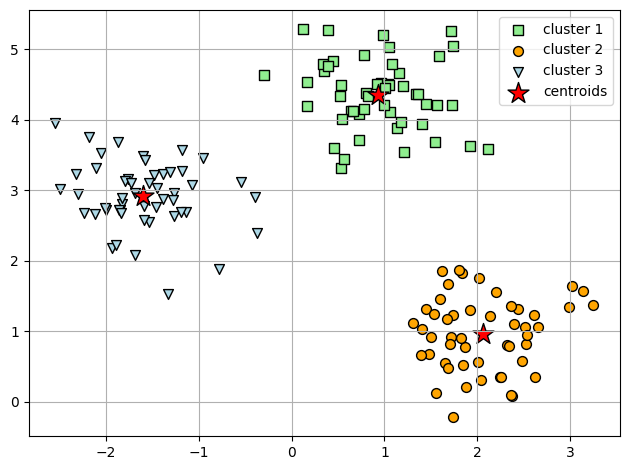

In [ ]:
plt.scatter(X[y_km == 0, 0],
            X[y_km == 0, 1],
            s=50, c='lightgreen',
            marker='s', edgecolor='black',
            label='cluster 1')
plt.scatter(X[y_km == 1, 0],
            X[y_km == 1, 1],
            s=50, c='orange',
            marker='o', edgecolor='black',
            label='cluster 2')
plt.scatter(X[y_km == 2, 0],
            X[y_km == 2, 1],
            s=50, c='lightblue',
            marker='v', edgecolor='black',
            label='cluster 3')
plt.scatter(km.cluster_centers_[:, 0],
            km.cluster_centers_[:, 1],
            s=250, marker='*',
            c='red', edgecolor='black',
            label='centroids')
plt.legend(scatterpoints=1)
plt.grid()
plt.tight_layout()
plt.show()

**엘보우 방법(Elbow Method)**은 군집 수를 늘려가며 관성(inertia, 왜곡도)의 변화를 관찰하여 적절한 $k$를 정하는 방법이다.

### Cluster 개수 정하기
- distrotion = 각 데이터 포인트와 해당 클러스터 중심 간의 제곱 거리의 합
- 감소폭이 더뎌지는 지점이 바로 적절한 클러스터 개수
- 이 지점 이전에는 클러스터 개수를 늘려도 모델의 성능 향상이 크지 않고, 이후에는 추가 클러스터링으로 인해 모델이 더 복잡해지면서 성능이 떨어질 수 있음

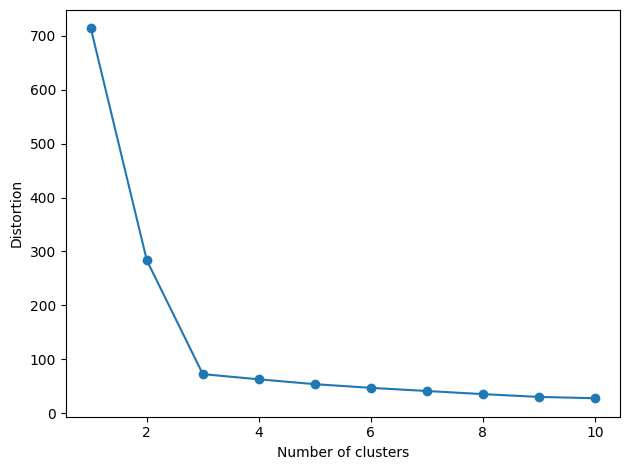

In [ ]:
distortions = []
for i in range(1, 11):
    km = KMeans(n_clusters=i,
                init='k-means++',
                n_init=10,
                max_iter=300,
                random_state=0)
    km.fit(X)
    distortions.append(km.inertia_)
plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.tight_layout()
plt.show()

**실루엣 분석(Silhouette Analysis)**은 군집화 품질을 정량화하는 지표로, 각 샘플의 실루엣 계수는 응집도와 분리도의 상대적 크기로 정의된다. 값은 $[-1, 1]$ 범위이며 클수록 군집화가 잘 된 것이다.

### 실루엣 분석
-  각 데이터 포인트가 해당 클러스터 내에서 얼마나 잘 클러스터링되었는지 표현
-  클러스터링 결과가 좋을수록 각 클러스터의 실루엣 계수가 높고, 전체 평균 실루엣 계수가 높음.
- sillouette = (b-a)/max(a,b)
  - a:한 데이터 포인트의 클러스터 내부 거리 (cohesion)
  - b: 한 데이터 포인트의 다른 클러스터와의 최근접 클러스터의 평균 거리

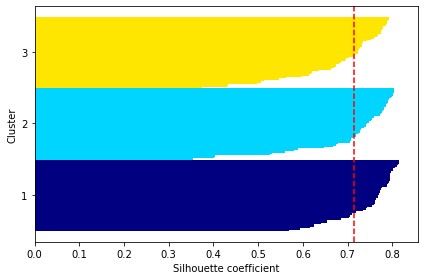

In [ ]:
import numpy as np
from matplotlib import cm
from sklearn.metrics import silhouette_samples

km = KMeans(n_clusters=3,
            init='k-means++',
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)
y_km = km.fit_predict(X)

cluster_labels = np.unique(y_km)
n_clusters = cluster_labels.shape[0]
silhouette_vals = silhouette_samples(X, y_km, metric='euclidean')
y_ax_lower, y_ax_upper = 0, 0
yticks = []
for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_km == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0,
             edgecolor='none', color=color)

    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)

silhouette_avg = np.mean(silhouette_vals)
plt.axvline(silhouette_avg, color="red", linestyle="--")

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')

plt.tight_layout()
plt.show()

### 클러스터링이 잘 안되었을 경우

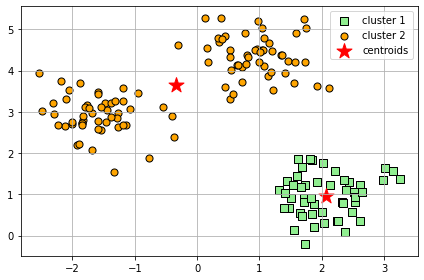

In [ ]:
km = KMeans(n_clusters=2,
            init='k-means++',
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)
y_km = km.fit_predict(X)

plt.scatter(X[y_km == 0, 0],
            X[y_km == 0, 1],
            s=50,
            c='lightgreen',
            edgecolor='black',
            marker='s',
            label='cluster 1')
plt.scatter(X[y_km == 1, 0],
            X[y_km == 1, 1],
            s=50,
            c='orange',
            edgecolor='black',
            marker='o',
            label='cluster 2')

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            s=250, marker='*', c='red', label='centroids')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

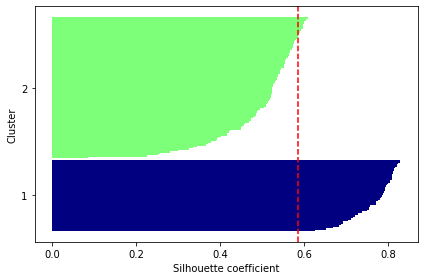

In [ ]:
cluster_labels = np.unique(y_km)
n_clusters = cluster_labels.shape[0]
silhouette_vals = silhouette_samples(X, y_km, metric='euclidean')
y_ax_lower, y_ax_upper = 0, 0
yticks = []
for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_km == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0,
             edgecolor='none', color=color)

    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)

silhouette_avg = np.mean(silhouette_vals)
plt.axvline(silhouette_avg, color="red", linestyle="--")

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')

plt.tight_layout()
plt.show()

### Hierarchcial Agglomerative Clustering

**계층적 병합 군집(Agglomerative Hierarchical Clustering)**은 각 샘플을 개별 군집으로 시작하여, 가장 가까운 두 군집을 반복적으로 병합해 군집 계층 구조를 형성하는 방법이다. 군집 수를 사전에 지정할 필요가 없으며, 병합 과정은 **덴드로그램(dendrogram)**으로 시각화된다.

군집 간 거리는 **연결 기준(linkage)**으로 정의된다. complete 연결은 두 군집 간 샘플 쌍의 최대 거리, single은 최소 거리, average는 평균 거리를 사용한다.

### 데이터 생성

In [8]:
import pandas as pd
import numpy as np

np.random.seed(123)

variables = ['X', 'Y', 'Z']
labels = ['ID_0', 'ID_1', 'ID_2', 'ID_3', 'ID_4']

X = np.random.random_sample([5, 3])*10
df = pd.DataFrame(X, columns=variables, index=labels)
df

,X,Y,Z
ID_0,6.964692,2.861393,2.268515
ID_1,5.513148,7.194690,4.231065
ID_2,9.807642,6.848297,4.809319
ID_3,3.921175,3.431780,7.290497
ID_4,4.385722,0.596779,3.980443


### 거리행렬 계산

In [9]:
from scipy.spatial.distance import pdist, squareform

row_dist = pd.DataFrame(squareform(pdist(df, metric='euclidean')),
                        columns=labels,
                        index=labels)

row_dist

,ID_0,ID_1,ID_2,ID_3,ID_4
ID_0,0.000000,4.973534,5.516653,5.899885,3.835396
ID_1,4.973534,0.000000,4.347073,5.104311,6.698233
ID_2,5.516653,4.347073,0.000000,7.244262,8.316594
ID_3,5.899885,5.104311,7.244262,0.000000,4.382864
ID_4,3.835396,6.698233,8.316594,4.382864,0.000000


### Linkage Matrix 생성
- 데이터 포인트 간의 거리 행렬을 입력으로 받아, 거리에 기반하여 클러스터 간의 유사성을 계산하고 클러스터 간의 연결 정보를 생성
- 참고: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html

In [10]:
from scipy.cluster.hierarchy import linkage
row_clusters = linkage(pdist(df, metric='euclidean'), method='complete')
pd.DataFrame(row_clusters,
             columns=['row label 1', 'row label 2',
                      'distance', 'no. of items in clust.'],
             index=['cluster %d' % (i + 1)
                    for i in range(row_clusters.shape[0])])

,row label 1,row label 2,distance,no. of items in clust.
cluster 1,0.0,4.0,3.835396,2.0
cluster 2,1.0,2.0,4.347073,2.0
cluster 3,3.0,5.0,5.899885,3.0
cluster 4,6.0,7.0,8.316594,5.0


### Dendrogram 그리기

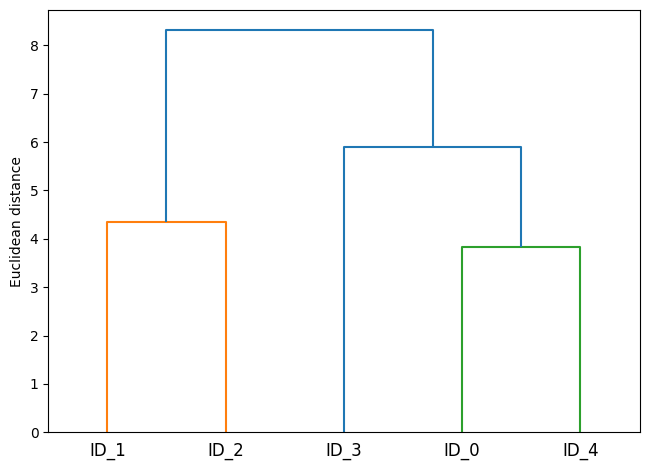

In [15]:
from scipy.cluster.hierarchy import dendrogram
from matplotlib import pyplot as plt
#make dendrogram black (part 1/2)
#from scipy.cluster.hierarchy import set_link_color_palette
#et_link_color_palette(['black'])

row_dendr = dendrogram(row_clusters,
                       labels=labels,
                       # make dendrogram black (part 2/2)
                       #color_threshold=np.inf
                       )
plt.tight_layout()
plt.ylabel('Euclidean distance')
plt.show()

### Scikit-Learn을 활용한 Agglomerative Clustering

In [ ]:
from sklearn.cluster import AgglomerativeClustering

ac = AgglomerativeClustering(n_clusters=3,
                             affinity='euclidean',
                             linkage='complete')
labels = ac.fit_predict(X)
print(ac)
print('Cluster labels: %s' % labels)

AgglomerativeClustering(linkage='complete', n_clusters=3)
Cluster labels: [1 0 0 2 1]


In [ ]:
ac = AgglomerativeClustering(n_clusters=2,
                             affinity='euclidean',
                             linkage='complete')
labels = ac.fit_predict(X)
print('Cluster labels: %s' % labels)

Cluster labels: [0 1 1 0 0]


## DBSCAN

**DBSCAN(Density-Based Spatial Clustering of Applications with Noise)**은 밀도 기반 군집화 알고리즘으로, 밀도가 높은 영역을 군집으로, 낮은 영역의 샘플을 잡음(이상치)으로 분류한다. 군집 수를 지정하지 않으며 임의 형태의 군집을 탐지할 수 있다.

두 하이퍼파라미터로 정의된다: **eps**는 이웃으로 간주할 반경, **min_samples**는 핵심 포인트가 되기 위한 이웃의 최소 개수이다. 반경 eps 내에 min_samples 이상의 이웃을 가지는 샘플을 **핵심 포인트(core point)**, 핵심 포인트의 이웃이지만 그 자체는 핵심이 아닌 샘플을 **경계 포인트(border point)**, 어디에도 속하지 않는 샘플을 **잡음(noise)**으로 구분한다.

**비볼록 구조에서의 한계.** 아래 반달(two-moons) 데이터는 볼록하지 않은 형태의 군집을 가진다. K-Means와 계층적 군집(complete linkage)은 이러한 구조를 올바르게 분리하지 못하는 반면, 밀도 기반의 DBSCAN은 임의 형태의 군집을 탐지할 수 있다.

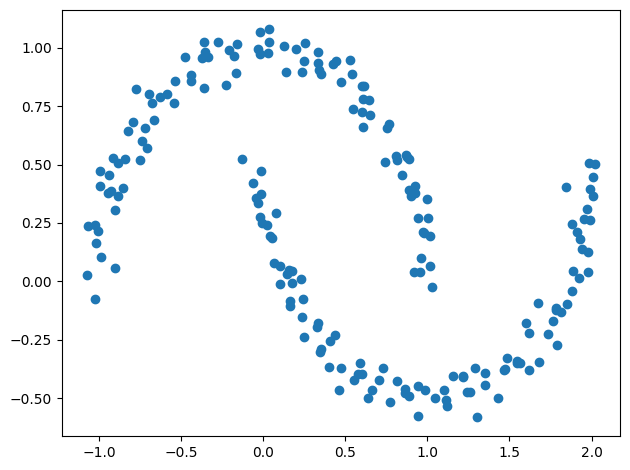

In [13]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)
plt.scatter(X[:, 0], X[:, 1])
plt.tight_layout()
plt.show()

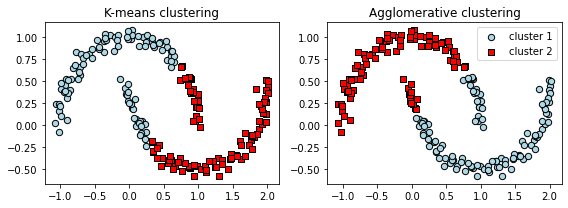

In [ ]:

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

km = KMeans(n_clusters=2, random_state=0)
y_km = km.fit_predict(X)

ax1.scatter(X[y_km == 0, 0], X[y_km == 0, 1],
           edgecolor='black',
           c='lightblue', marker='o', s=40, label='cluster 1')
ax1.scatter(X[y_km == 1, 0], X[y_km == 1, 1],
           edgecolor='black',
           c='red', marker='s', s=40, label='cluster 2')
ax1.set_title('K-means clustering')

ac = AgglomerativeClustering(n_clusters=2,
                             affinity='euclidean',
                             linkage='complete')
y_ac = ac.fit_predict(X)
ax2.scatter(X[y_ac == 0, 0], X[y_ac == 0, 1], c='lightblue',
            edgecolor='black',
            marker='o', s=40, label='cluster 1')
ax2.scatter(X[y_ac == 1, 0], X[y_ac == 1, 1], c='red',
            edgecolor='black',
            marker='s', s=40, label='cluster 2')
ax2.set_title('Agglomerative clustering')

plt.legend()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, '20 K-means clustering')

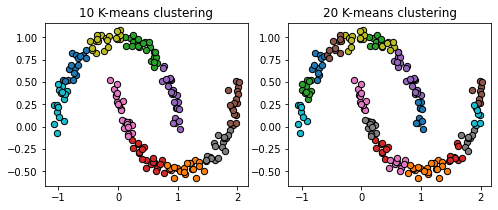

In [ ]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

km = KMeans(n_clusters=10, random_state=0)
y_km = km.fit_predict(X)
for i in range (10):
    ax1.scatter(X[y_km == i, 0], X[y_km == i, 1],
           edgecolor='black',
            marker='o', s=40, label='cluster'+str(i))
ax1.set_title('10 K-means clustering')

km = KMeans(n_clusters=20, random_state=0)
y_km = km.fit_predict(X)
for i in range (20):
    ax2.scatter(X[y_km == i, 0], X[y_km == i, 1],
           edgecolor='black',
            marker='o', s=40, label='cluster'+str(i))
ax2.set_title('20 K-means clustering')

- dbscan: 밀도기반 클러스터링 군집화 알고리즘
- 밀도가 높은 지역을 클러스터로 인식하고 밀도가 낮은 지역을 이상치로 처리
- 클러스터의 모양에 대해 가정을 하지 않기 때문에, 임의 모양의 클러스터도 잘 인식
- eps 내에 존재하는 데이터 포인트를 이웃으로 간주
- core point: eps 내에 최소 데이터 포인트 개수(min_samples) 이상의 이웃을 가지는 데이터 포인트

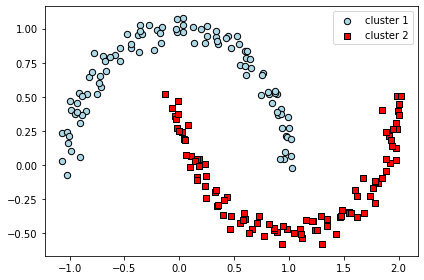

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.2, min_samples=5, metric='euclidean')
y_db = db.fit_predict(X)
plt.scatter(X[y_db == 0, 0], X[y_db == 0, 1],
            c='lightblue', marker='o', s=40,
            edgecolor='black',
            label='cluster 1')
plt.scatter(X[y_db == 1, 0], X[y_db == 1, 1],
            c='red', marker='s', s=40,
            edgecolor='black',
            label='cluster 2')
plt.legend()
plt.tight_layout()
plt.show()